Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [2]:
# Transactionnel
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_35664\2917235181.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_35664\2917235181.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_35664\2917235181.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [3]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 2002].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.5

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

## Calcul du traitement

### RNP

In [4]:
df_rnp = traitement(df_rnp)

### RP

In [5]:
df_rp = traitement(df_rp)

### UI

In [6]:
df_ui = traitement(df_ui)

### UD

In [7]:
df_ud = traitement(df_ud)

## DID

Definition du modele

In [ ]:
def DID (df) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [1995, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=['vote_RN_pres', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres['vote_RN_pres'] = df_pres['vote_RN_pres'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('int64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome='vote_RN_pres',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=3,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

In [25]:
df_rnp[(df_rnp['traitée']==1)&(df_rnp['Annee']==2022)].count()

codecommune          2130
Annee                2130
pop                  2130
propf                2130
prop014              2130
prop1539             2130
prop4059             2130
prop60p              2130
petranger            2127
pcapi                2124
pouem                2124
paind                2124
pchom                2124
pbac                 2130
psup                 2130
revmoy               2129
vote_EG_pres         2127
abstention_pres      2129
vote_RN_pres         2127
vote_EG_leg          2129
abstention_leg       2129
vote_RN_leg          2129
total_equipements    2130
seuil                2130
traitée              2130
dtype: int64

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000122 0.001484 -0.002786  0.003031 39612.0     1057.0 39612.0       1057.0
            Effect_2 -0.000534 0.002003 -0.004459  0.003392 29486.0      925.0 29486.0        925.0
            Effect_3 -0.007134 0.002614 -0.012258 -0.002010 19555.0      713.0 19555.0        713.0
Average_Total_Effect -0.002023 0.001525 -0.005012  0.000967 41269.0     2695.0 41269.0       2695.0
           Placebo_1  0.001366 0.001803 -0.002168  0.004900 29151.0      609.0 29151.0        609.0
           Placebo_2 -0.001656 0.002807 -0.007158  0.003845  9551.0      213.0  9551.0        213.0
Test of joint nullity of the effects: p-value = 0.029805
Test of joint nullity of the placebos: p-value = 0.504836

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


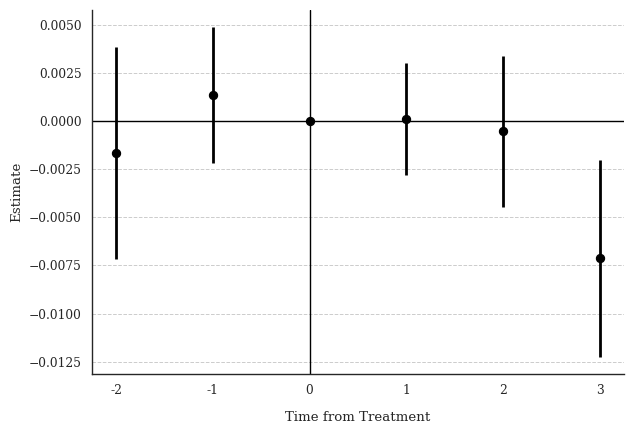

In [28]:
DID(df_rnp)

In [26]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = -0.003850
se_placebo =   0.001352 

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : -2.848
P-value du Placebo : 0.004


### RP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000722 0.001542 -0.003745  0.002301 40195.0      945.0 40195.0        945.0
            Effect_2 -0.002267 0.001864 -0.005921  0.001386 30001.0      839.0 30001.0        839.0
            Effect_3 -0.006058 0.002525 -0.011007 -0.001109 19967.0      678.0 19967.0        678.0
Average_Total_Effect -0.002718 0.001490 -0.005639  0.000202 41716.0     2462.0 41716.0       2462.0
           Placebo_1  0.000251 0.002035 -0.003737  0.004239 29643.0      485.0 29643.0        485.0
           Placebo_2 -0.002190 0.003818 -0.009672  0.005292  9750.0      163.0  9750.0        163.0
Test of joint nullity of the effects: p-value = 0.120303
Test of joint nullity of the placebos: p-value = 0.782386

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


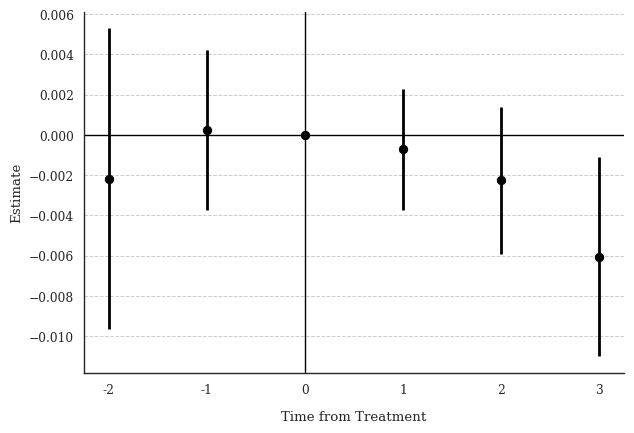

In [29]:
DID(df_rp)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000114 0.002169 -0.004137 0.004364 14941.0      230.0 14941.0        230.0
            Effect_2  0.001138 0.002828 -0.004404 0.006680 11875.0      214.0 11875.0        214.0
            Effect_3  0.001319 0.004105 -0.006726 0.009364  8892.0      190.0  8892.0        190.0
Average_Total_Effect  0.000821 0.002651 -0.004375 0.006016 15346.0      634.0 15346.0        634.0
           Placebo_1  0.001020 0.002261 -0.003413 0.005452 11827.0      167.0 11827.0        167.0
           Placebo_2  0.006093 0.005655 -0.004990 0.017175  5838.0       59.0  5838.0         59.0
Test of joint nullity of the effects: p-value = 0.968621
Test of joint nullity of the placebos: p-value = 0.556577

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


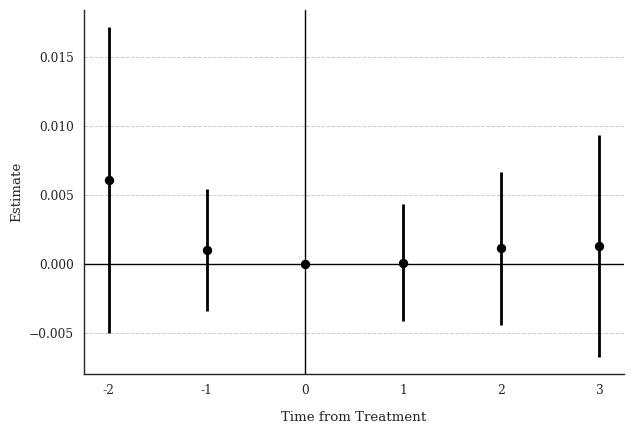

In [12]:
DID(df_ui)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI      N  Switchers    N.w  Switchers.w
            Effect_1 -0.002937 0.006039 -0.014773 0.008899 2009.0        4.0 2009.0          4.0
            Effect_2 -0.002559 0.009207 -0.020604 0.015486 2007.0        4.0 2007.0          4.0
            Effect_3  0.020609 0.024326 -0.027069 0.068286 1338.0        3.0 1338.0          3.0
Average_Total_Effect  0.003622 0.009105 -0.014223 0.021467 3351.0       11.0 3351.0         11.0
           Placebo_1 -0.012366 0.012547 -0.036958 0.012226 1337.0        2.0 1337.0          2.0
           Placebo_2 -0.041102 0.041029 -0.121517 0.039312  668.0        1.0  668.0          1.0
Test of joint nullity of the effects: p-value = 0.296126
Test of joint nullity of the placebos: p-value = 0.375292

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


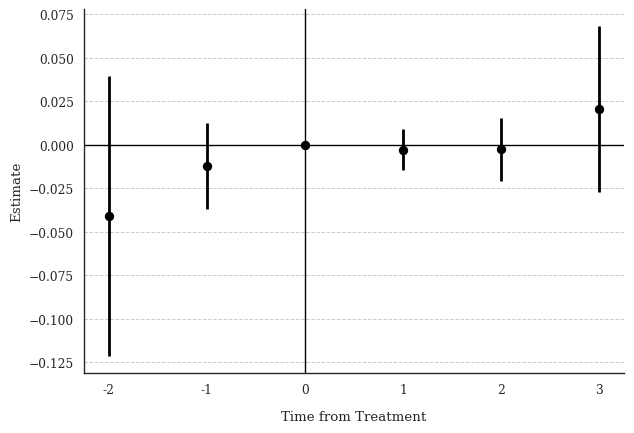

In [13]:
DID(df_ud)